In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from model import LogisticRegression
import kagglehub
import os
import joblib

# Download latest version
path = kagglehub.dataset_download("vivekgediya/banknote-authenticationcsv")

print("Path to dataset files:", path)

dataset_path = os.path.join(path , 'BankNote_Authentication.csv')

Path to dataset files: /home/ashish-d/.cache/kagglehub/datasets/vivekgediya/banknote-authenticationcsv/versions/1


In [21]:
training_df = pd.read_csv(dataset_path)
x_variable = training_df.loc[:,['variance', 'skewness', 'curtosis', 'entropy']]
y_variable = training_df.loc[:,['class']]
x_train,x_test,y_train,y_test = train_test_split(x_variable, y_variable, test_size = 0.30)

In [22]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
x_train_scaled = scaler.fit_transform(x_train.values)

# --- IMPORTANT ---
# Use that *same* scaler to transform your test data
x_test_scaled = scaler.transform(x_test.values)

# Now, train your model on the SCALED data
model = LogisticRegression()
model.fit(x_train_scaled, y_train.values.ravel(), epochs = 200)
y_pred = model.predict(x_test_scaled)

# And predict on the SCALED test data
predictions = model.predict(x_test_scaled)
print(predictions)
#
# # Now plot your results
# plt.scatter(y_test, predictions)
# print(model.class_class())



Epoch : 20 Loss : 0.280465
Epoch : 40 Loss : 0.197319
Epoch : 60 Loss : 0.156683
Epoch : 80 Loss : 0.132644
Epoch : 100 Loss : 0.116782
Epoch : 120 Loss : 0.105515
Epoch : 140 Loss : 0.097077
Epoch : 160 Loss : 0.090503
Epoch : 180 Loss : 0.085221
Epoch : 200 Loss : 0.080873
[1 1 1 1 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 0 0 1 0 1 1 1 0
 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 1 1 0 0 0 0 1 1 1 0 1 0 0 0 1 1 1 0
 1 0 0 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1
 1 0 0 0 1 1 1 1 1 0 0 0 1 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0 1 0
 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0
 0 0 0 1 1 0 0 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1
 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 1 1 1 0 1 0 0 0 1 0
 1 0 1 0 1 1 1 1 0 1 0 1 1 0 1 0 0 0 0 0 1 0 1 1 0 0 0 1 1 0 1 0 0 1 0 0 0
 0 1 0 1 0 1 0 0 1 0 1 1 0 1 1 0 0 1 0 0 1 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0
 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 

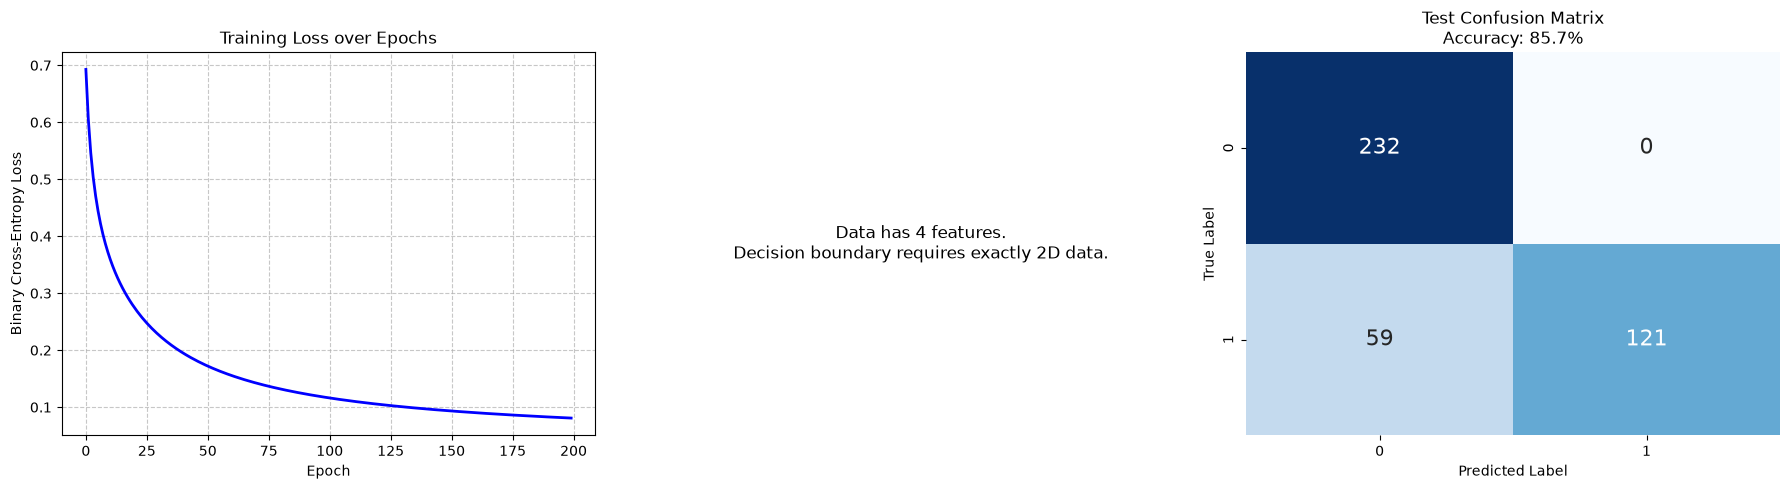

In [23]:
from model import visualize_training_and_evaluation

visualize_training_and_evaluation(model , x_train , y_train , x_test ,y_test)

In [26]:
data = {
    'model' : model,
    'scaler' : scaler
}

joblib.dump(data , "weights.pkl")

print("Weights saved!")

Weights saved!
